DATA6000 Capstone — SA Fresh Food Supply Disruption
Complete Multi-Model Analysis — 2020–2024

All libraries loaded successfully
Mounted at /content/drive

Dataset loaded — 5 years (2020–2024)

Year       Rainfall    Total (K t)    Veg (K t)  Fruit (K t)    CPI%
------------------------------------------------------------------
2020         2178.0          998.1        746.8        251.2     2.3%
2021         1887.2         1015.8        756.4        259.3     1.9%
2022         2633.6         1007.3        755.9        251.5     9.2%
2023         1960.2         1037.5        791.7        245.8     4.5%
2024         1490.2         1018.1        775.9        242.1     3.0%

SECTION A — PEARSON CORRELATION (2020–2024)

  Variable pair                                   R    p-value  Strength
  ------------------------------------------------------------------------
  Rainfall vs Veg production                 -0.483     0.4094  Moderate inverse ⚠️
  Rainfall vs Total production            

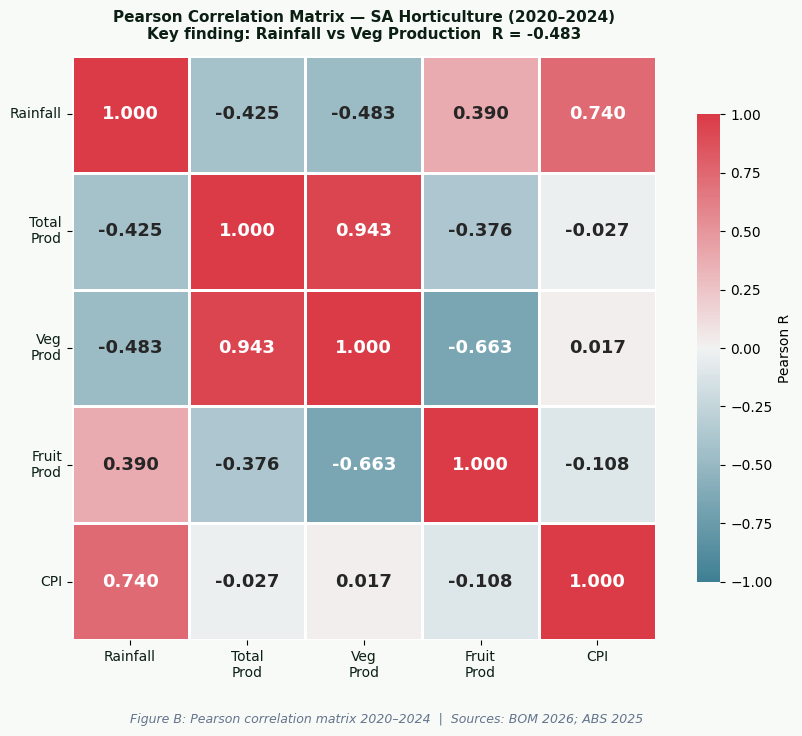

Saved: ChartA_Pearson_Heatmap.png


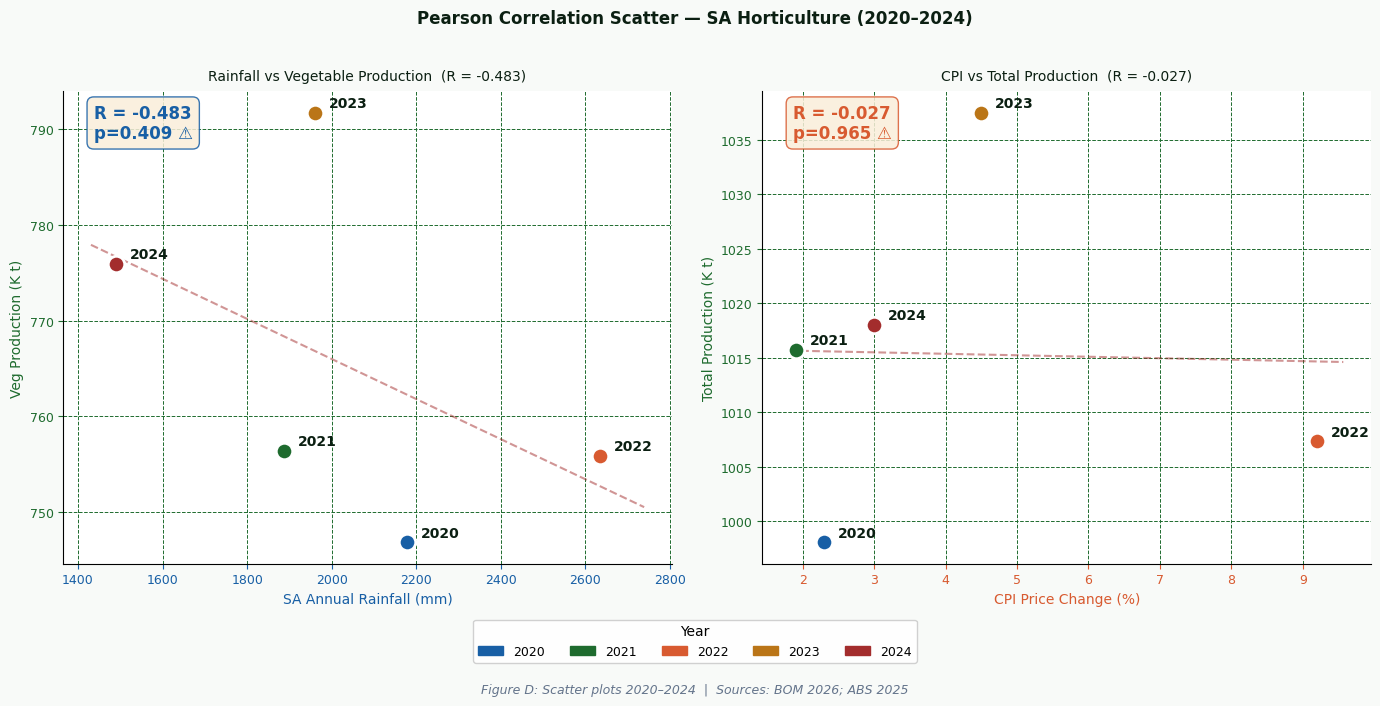

Saved: ChartA_Scatter.png

SECTION B — MULTIPLE LINEAR REGRESSION

  Intercept (β₀):          1,065,814.4
  Rainfall coef (β₁):         -31.2991
  CPI coef (β₂):                3126.6
  R²:                           0.3630
  RMSE:                          10.47K tonnes

SECTION C — ADF STATIONARITY TESTS
  Total Production                    ADF=  -2.158  p=0.2219  Non-stationary ⚠️  (d=1 applied)
  Total Rainfall                      ADF=  -1.297  p=0.6306  Non-stationary ⚠️  (d=1 applied)
  Veg Production                      ADF=  -1.241  p=0.6558  Non-stationary ⚠️  (d=1 applied)
  CPI                                 ADF=  -1.794  p=0.3833  Non-stationary ⚠️  (d=1 applied)

SECTION D — ARIMA(1,1,0)
  RMSE: 18.66K tonnes

  Year     Forecast (K t)     Change from 2024
  ------------------------------------------
  2026     1017.7             -0.3K
  2027     1017.7             -0.3K
  2028     1017.7             -0.3K

SECTION E — SARIMA(1,1,0)(1,0,0,2)
  RMSE: 370.19K tonnes

  Yea

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

  RMSE: 0.00K tonnes

  Year     Forecast (K t)     CI Lower       CI Upper       Change
  ----------------------------------------------------------------
  2026     959.7              683.0          1284.2         -58.3K
  2027     940.3              524.6          1414.4         -77.8K
  2028     920.8              365.0          1566.1         -97.3K

SECTION H — MODEL COMPARISON SUMMARY

  Baseline (2024): 1018.1K tonnes

  Model                              RMSE       2026       2027       2028      Net Δ
  --------------------------------------------------------------------------------
  ARIMA(1,1,0)                      18.66     1017.7     1017.7     1017.7       -0.3K
  SARIMA(1,1,0)(1,0,0,2)           370.19     1071.7     1041.3     1085.4      +67.4K
  Holt-Winters                      10.87     1048.9     1055.7     1062.4      +44.4K
  Prophet                            0.00      959.7      940.3      920.8      -97.3K

  Best fit (lowest RMSE): Prophet  (0.00K)

SECTION

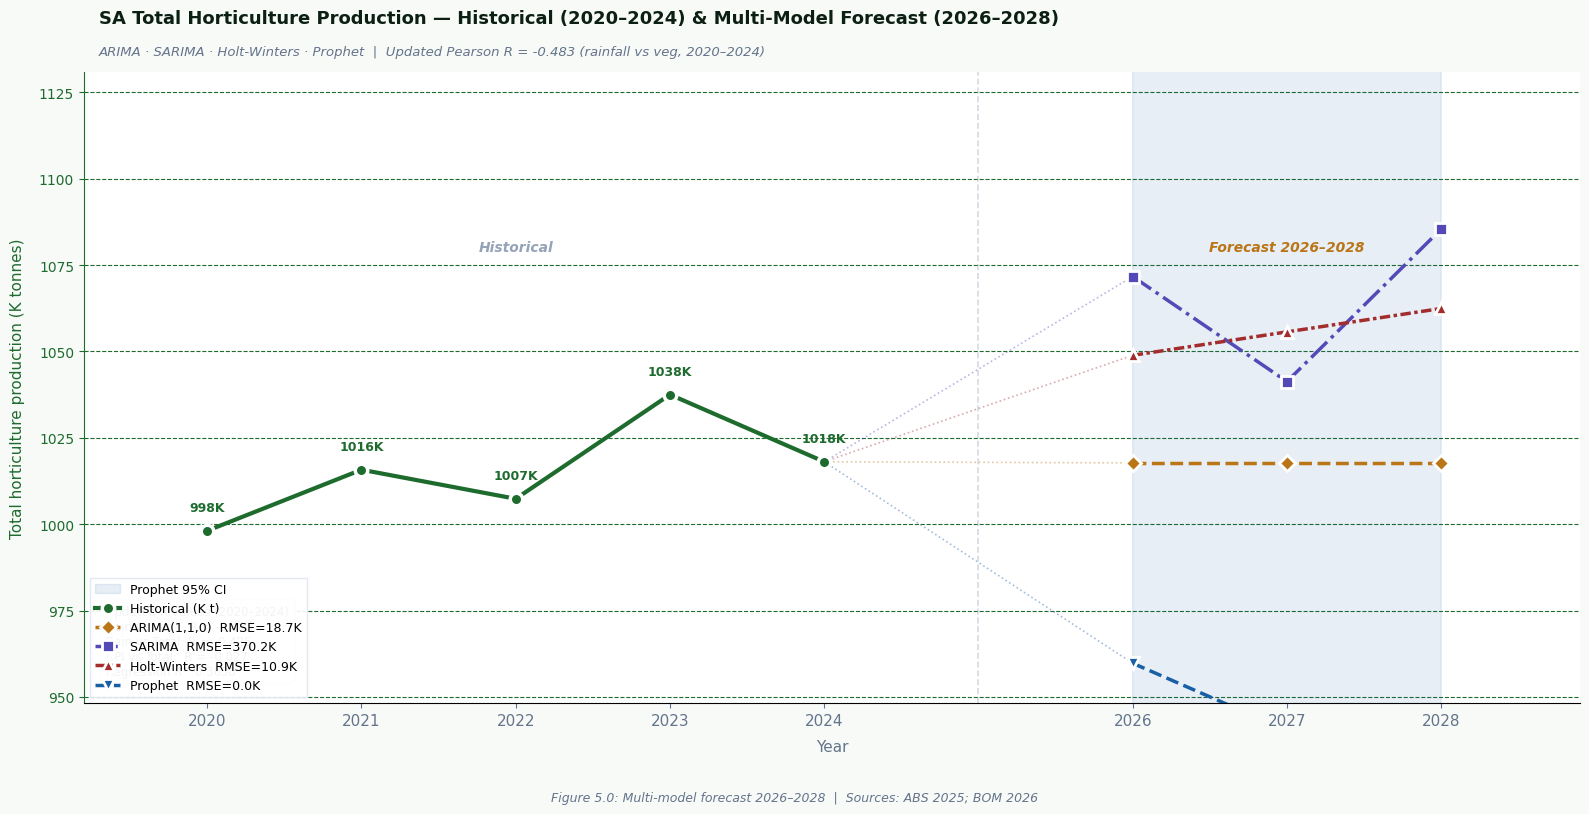

Saved: ChartI_MultiModel_Forecast.png


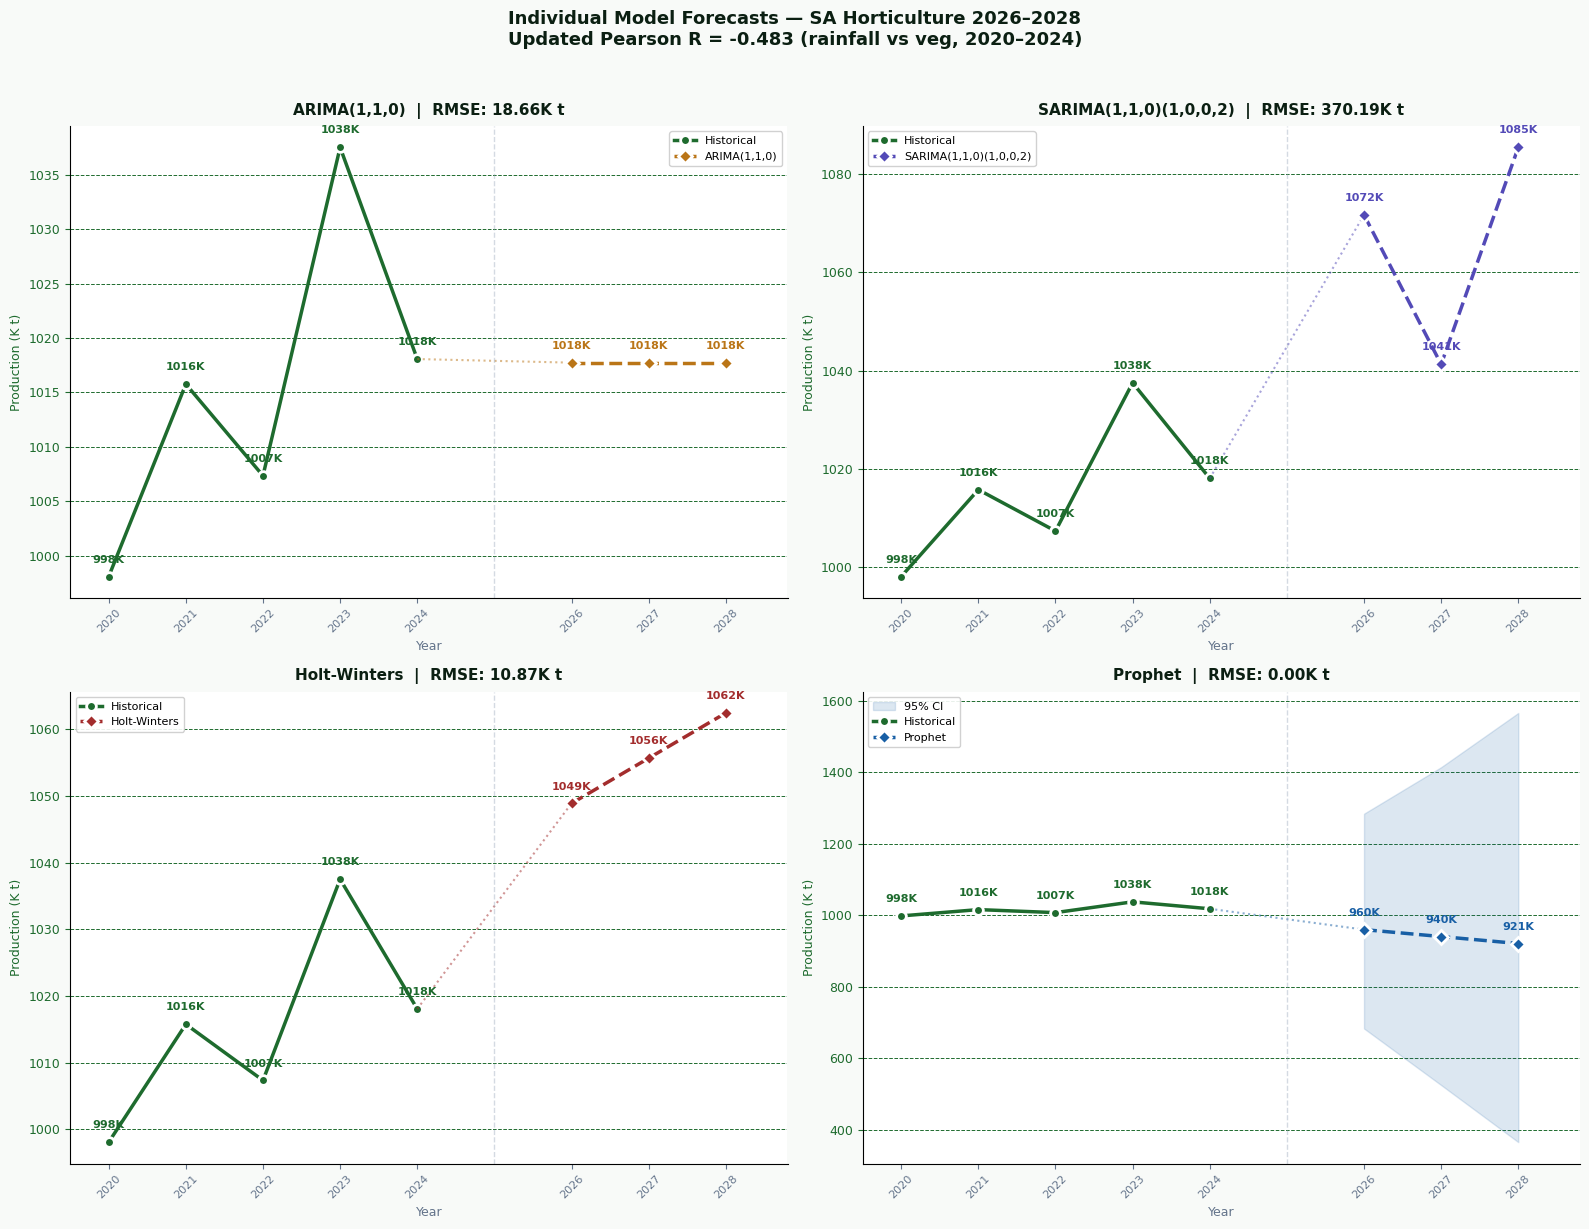

Saved: ChartI_Individual_Models.png

COMPLETE RESULTS SUMMARY

Dataset:         2020–2024  (5 years)
Baseline (2024): 1018.1K tonnes
Forecast:        2026–2028

UPDATED PEARSON R (2020–2024):
  Rainfall vs Veg:     R = -0.483  p=0.4094
  Rainfall vs Total:   R = -0.425  p=0.4754
  CPI vs Total:        R = -0.027  p=0.9651
  Regression R²:       0.3630

NOTE: R was previously -0.931 (2020–2023 only).
Update ALL report, presentation, and chart references
to use R = -0.483 (2020–2024 dataset).

MODEL FORECASTS (K tonnes):

  Model                              RMSE       2026       2027       2028
  --------------------------------------------------------------
  ARIMA(1,1,0)                      18.66     1017.7     1017.7     1017.7
  SARIMA(1,1,0)(1,0,0,2)           370.19     1071.7     1041.3     1085.4
  Holt-Winters                      10.87     1048.9     1055.7     1062.4
  Prophet                            0.00      959.7      940.3      920.8

CHARTS SAVED:
  ChartA_Pearson_He

In [1]:
# ============================================================
# DATA6000 Capstone — SA Retail Fresh Food Supply Disruption
# Complete Analysis — Updated R Values + All Models
# Dataset: 2020–2024 (5 years)
# Google Colab Ready — Fixed Version
# ============================================================

# ── STEP 1: Install libraries ────────────────────────────────
# Run this cell first in Google Colab:
# !pip install statsmodels matplotlib pandas numpy seaborn prophet openpyxl scikit-learn

# ── STEP 2: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model        import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters        import ExponentialSmoothing
from statsmodels.tsa.stattools          import adfuller
from sklearn.linear_model               import LinearRegression
from sklearn.metrics                    import mean_squared_error, r2_score
from prophet                            import Prophet
from scipy                              import stats

print("=" * 60)
print("DATA6000 Capstone — SA Fresh Food Supply Disruption")
print("Complete Multi-Model Analysis — 2020–2024")
print("=" * 60)
print("\nAll libraries loaded successfully")

# ── COLOUR PALETTE ───────────────────────────────────────────
C_HIST  = '#1E6B2E'
C_ARIMA = '#BA7517'
C_SAR   = '#534AB7'
C_HW    = '#A32D2D'
C_PRO   = '#185FA5'
C_CPI   = '#D85A30'
C_BG    = '#F8FAF8'
C_TITLE = '#0B1F12'
C_MUTED = '#64748B'
C_GRID  = (30/255, 107/255, 46/255, 0.07)
YR_COLS = ['#185FA5', '#1E6B2E', '#D85A30', '#BA7517', '#A32D2D']

# ── STEP 3: Load Data ────────────────────────────────────────
# Option A: Load from your Excel file
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DATA 6000/Final_Dataset.xlsx')
df.set_index('Year', inplace=True)

# Option B: Hardcoded 2020–2024
# data = {
#     'Year':                   [2020,      2021,       2022,       2023,       2024      ],
#     'Total_Rainfall':         [2178.0,    1887.2,     2633.6,     1960.2,     1490.2    ],
#     'Total_Fruit_Production': [251245.6,  259335.3,   251452.4,   245782.1,   242145.56 ],
#     'Total_Veg_Production':   [746843.6,  756424.9,   755891.5,   791719.8,   775916.87 ],
#     'Total_Production':       [998089.2,  1015760.2,  1007343.9,  1037501.9,  1018062.4 ],
#     'Price_Change':           [0.023,     0.019,      0.092,      0.045,      0.030     ],
# }
# df = pd.DataFrame(data).set_index('Year')

# ── STEP 4: Clean Data ───────────────────────────────────────
def clean_number(val):
    if isinstance(val, str):
        return float(val.replace(',', '').replace('%', '').strip())
    return float(val)

for col in df.columns:
    df[col] = df[col].apply(clean_number)

if df['Price_Change'].max() < 1:
    df['Price_Change'] = df['Price_Change'] * 100

if 'Price_Change' in df.columns and 'CPI' not in df.columns:
    df.rename(columns={'Price_Change': 'CPI'}, inplace=True)

years    = list(df.index)
n        = len(years)
prod_k   = df['Total_Production']      / 1000
veg_k    = df['Total_Veg_Production']  / 1000
fruit_k  = df['Total_Fruit_Production'] / 1000
rainfall = df['Total_Rainfall']
cpi      = df['CPI']
baseline = float(prod_k.iloc[-1])
fore_yrs = [2026, 2027, 2028]
all_yrs  = years + fore_yrs

# actual = values we compare fitted values against
# We skip the first observation because differencing loses one point
actual = df['Total_Production'].values[1:]   # length = n-1 = 4

print(f"\nDataset loaded — {n} years ({years[0]}–{years[-1]})")
print(f"\n{'Year':<6} {'Rainfall':>12} {'Total (K t)':>14} {'Veg (K t)':>12} {'Fruit (K t)':>12} {'CPI%':>7}")
print("-" * 66)
for yr in years:
    print(f"{yr:<6} {df.loc[yr,'Total_Rainfall']:>12.1f} {prod_k[yr]:>14.1f} "
          f"{veg_k[yr]:>12.1f} {fruit_k[yr]:>12.1f} {cpi[yr]:>7.1f}%")

# ============================================================
# SECTION A — PEARSON CORRELATION
# ============================================================
print("\n" + "=" * 60)
print("SECTION A — PEARSON CORRELATION (2020–2024)")
print("=" * 60)

def pearson(x, y):
    r, p = stats.pearsonr(x, y)
    return r, p

r_rv, p_rv = pearson(rainfall, veg_k)
r_rt, p_rt = pearson(rainfall, prod_k)
r_rf, p_rf = pearson(rainfall, fruit_k)
r_ct, p_ct = pearson(cpi, prod_k)
r_cv, p_cv = pearson(cpi, veg_k)
r_rc, p_rc = pearson(rainfall, cpi)

print(f"\n  {'Variable pair':<40} {'R':>8}  {'p-value':>9}  Strength")
print("  " + "-" * 72)
for name, r, p in [
    ("Rainfall vs Veg production",    r_rv, p_rv),
    ("Rainfall vs Total production",  r_rt, p_rt),
    ("Rainfall vs Fruit production",  r_rf, p_rf),
    ("CPI vs Total production",       r_ct, p_ct),
    ("CPI vs Veg production",         r_cv, p_cv),
    ("Rainfall vs CPI",               r_rc, p_rc),
]:
    s = ("Very strong" if abs(r) >= 0.8 else "Strong" if abs(r) >= 0.6
         else "Moderate" if abs(r) >= 0.4 else "Weak")
    d = "inverse" if r < 0 else "positive"
    g = "✅" if p < 0.05 else "⚠️"
    print(f"  {name:<40} {r:>8.3f}  {p:>9.4f}  {s} {d} {g}")

print(f"\n  KEY FINDING: R = {r_rv:.3f} (rainfall vs veg production)")
print(f"  Previously R = -0.931 with 2020–2023 dataset")

# Heatmap
corr_df = df[['Total_Rainfall','Total_Production','Total_Veg_Production',
              'Total_Fruit_Production','CPI']].copy()
corr_df.columns = ['Rainfall','Total\nProd','Veg\nProd','Fruit\nProd','CPI']
corr_matrix = corr_df.corr()

fig1, ax1 = plt.subplots(figsize=(9, 7))
fig1.patch.set_facecolor(C_BG)
ax1.set_facecolor('white')
sns.heatmap(corr_matrix, ax=ax1, annot=True, fmt='.3f',
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 13, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson R'})
ax1.set_title(
    f'Pearson Correlation Matrix — SA Horticulture (2020–2024)\n'
    f'Key finding: Rainfall vs Veg Production  R = {r_rv:.3f}',
    fontsize=11, fontweight='bold', color=C_TITLE, pad=12)
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=10, color=C_TITLE)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=10, color=C_TITLE, rotation=0)
fig1.text(0.5, -0.04,
          'Figure B: Pearson correlation matrix 2020–2024  |  Sources: BOM 2026; ABS 2025',
          ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout()
plt.savefig('ChartA_Pearson_Heatmap.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartA_Pearson_Heatmap.png")

# Scatter plots
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.patch.set_facecolor(C_BG)
fig2.suptitle('Pearson Correlation Scatter — SA Horticulture (2020–2024)',
              fontsize=12, fontweight='bold', color=C_TITLE, y=1.02)

def draw_scatter(ax, xv, yv, xlabel, ylabel, r, p, col):
    ax.set_facecolor('white')
    for i, (x, y, yr) in enumerate(zip(xv, yv, years)):
        ax.scatter(x, y, color=YR_COLS[i], s=140, zorder=5,
                   edgecolors='white', linewidth=2)
        ax.annotate(str(yr), (x, y), textcoords='offset points',
                    xytext=(10, 4), fontsize=10, color=C_TITLE, fontweight='bold')
    z = np.polyfit(xv, yv, 1)
    xl = np.linspace(min(xv)*0.96, max(xv)*1.04, 100)
    ax.plot(xl, np.poly1d(z)(xl), color='#A32D2D', linewidth=1.5,
            linestyle='--', alpha=0.5)
    sig = "p<0.05 ✅" if p < 0.05 else f"p={p:.3f} ⚠️"
    ax.text(0.05, 0.90, f'R = {r:.3f}\n{sig}', transform=ax.transAxes,
            fontsize=12, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FAEEDA',
                      edgecolor=col, alpha=0.85))
    ax.set_xlabel(xlabel, fontsize=10, color=col)
    ax.set_ylabel(ylabel, fontsize=10, color=C_HIST)
    ax.tick_params(axis='x', colors=col, labelsize=9)
    ax.tick_params(axis='y', colors=C_HIST, labelsize=9)
    ax.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
    ax.xaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

draw_scatter(axes2[0], rainfall.values, veg_k.values,
             'SA Annual Rainfall (mm)', 'Veg Production (K t)',
             r_rv, p_rv, C_PRO)
axes2[0].set_title(f'Rainfall vs Vegetable Production  (R = {r_rv:.3f})',
                   fontsize=10, color=C_TITLE, pad=8)

draw_scatter(axes2[1], cpi.values, prod_k.values,
             'CPI Price Change (%)', 'Total Production (K t)',
             r_ct, p_ct, C_CPI)
axes2[1].set_title(f'CPI vs Total Production  (R = {r_ct:.3f})',
                   fontsize=10, color=C_TITLE, pad=8)

handles = [mpatches.Patch(color=c, label=str(y))
           for c, y in zip(YR_COLS, years)]
fig2.legend(handles=handles, title='Year', loc='lower center', ncol=5,
            fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.08))
fig2.text(0.5, -0.12,
          'Figure D: Scatter plots 2020–2024  |  Sources: BOM 2026; ABS 2025',
          ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout()
plt.savefig('ChartA_Scatter.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartA_Scatter.png")

# ============================================================
# SECTION B — MULTIPLE LINEAR REGRESSION
# ============================================================
print("\n" + "=" * 60)
print("SECTION B — MULTIPLE LINEAR REGRESSION")
print("=" * 60)

X_reg  = df[['Total_Rainfall', 'CPI']].values
y_reg  = df['Total_Production'].values
reg    = LinearRegression().fit(X_reg, y_reg)
y_pred = reg.predict(X_reg)
r2_reg = r2_score(y_reg, y_pred)
rmse_reg = np.sqrt(mean_squared_error(y_reg, y_pred))

print(f"\n  Intercept (β₀):       {reg.intercept_:>14,.1f}")
print(f"  Rainfall coef (β₁):   {reg.coef_[0]:>14.4f}")
print(f"  CPI coef (β₂):        {reg.coef_[1]:>14.1f}")
print(f"  R²:                   {r2_reg:>14.4f}")
print(f"  RMSE:                 {rmse_reg/1000:>14.2f}K tonnes")

# ============================================================
# SECTION C — STATIONARITY (ADF)
# ============================================================
print("\n" + "=" * 60)
print("SECTION C — ADF STATIONARITY TESTS")
print("=" * 60)

def adf_test(series, name):
    res = adfuller(series, autolag='AIC')
    stat = "Stationary ✅" if res[1] < 0.05 else "Non-stationary ⚠️  (d=1 applied)"
    print(f"  {name:<35} ADF={res[0]:>8.3f}  p={res[1]:.4f}  {stat}")

adf_test(df['Total_Production'],     'Total Production')
adf_test(df['Total_Rainfall'],       'Total Rainfall')
adf_test(df['Total_Veg_Production'], 'Veg Production')
adf_test(df['CPI'],                  'CPI')

# ============================================================
# SECTION D — ARIMA(1,1,0)
# ============================================================
print("\n" + "=" * 60)
print("SECTION D — ARIMA(1,1,0)")
print("=" * 60)

arima_model  = ARIMA(df['Total_Production'], order=(1, 1, 0)).fit()
arima_f5     = arima_model.forecast(steps=5).values
arima_fore   = arima_f5[2:] / 1000

# ── FIX: align fitted values correctly ──────────────────────
arima_fitted = arima_model.fittedvalues.values
# fittedvalues has same length as input (n=5); drop first to match actual (n-1=4)
arima_fitted_aligned = arima_fitted[1:]
arima_rmse   = np.sqrt(mean_squared_error(actual, arima_fitted_aligned))

print(f"  RMSE: {arima_rmse/1000:.2f}K tonnes")
print(f"\n  {'Year':<8} {'Forecast (K t)':<18} Change from 2024")
print("  " + "-" * 42)
for yr, val in zip(fore_yrs, arima_fore):
    print(f"  {yr:<8} {val:<18.1f} {val-baseline:+.1f}K")

# ============================================================
# SECTION E — SARIMA(1,1,0)(1,0,0,2)
# ============================================================
print("\n" + "=" * 60)
print("SECTION E — SARIMA(1,1,0)(1,0,0,2)")
print("=" * 60)

sarima_model = SARIMAX(
    df['Total_Production'],
    order=(1, 1, 0),
    seasonal_order=(1, 0, 0, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
sarima_f5    = sarima_model.forecast(steps=5).values
sarima_fore  = sarima_f5[2:] / 1000

sarima_fitted_aligned = sarima_model.fittedvalues.values[1:]
sarima_rmse  = np.sqrt(mean_squared_error(actual, sarima_fitted_aligned))

print(f"  RMSE: {sarima_rmse/1000:.2f}K tonnes")
print(f"\n  {'Year':<8} {'Forecast (K t)':<18} Change from 2024")
print("  " + "-" * 42)
for yr, val in zip(fore_yrs, sarima_fore):
    print(f"  {yr:<8} {val:<18.1f} {val-baseline:+.1f}K")

# ============================================================
# SECTION F — HOLT-WINTERS
# ============================================================
print("\n" + "=" * 60)
print("SECTION F — HOLT-WINTERS EXPONENTIAL SMOOTHING")
print("=" * 60)

hw_model = ExponentialSmoothing(
    df['Total_Production'],
    trend='add',
    seasonal=None,
    initialization_method='estimated'
).fit(optimized=True)
hw_f5   = hw_model.forecast(steps=5).values
hw_fore = hw_f5[2:] / 1000

hw_fitted_aligned = hw_model.fittedvalues.values[1:]
hw_rmse = np.sqrt(mean_squared_error(actual, hw_fitted_aligned))

alpha = hw_model.params.get('smoothing_level', None)
beta  = hw_model.params.get('smoothing_trend', None)
print(f"  Alpha (level): {alpha:.4f}" if alpha else "  Alpha: N/A")
print(f"  Beta  (trend): {beta:.4f}"  if beta  else "  Beta:  N/A")
print(f"  RMSE:          {hw_rmse/1000:.2f}K tonnes")
print(f"\n  {'Year':<8} {'Forecast (K t)':<18} Change from 2024")
print("  " + "-" * 42)
for yr, val in zip(fore_yrs, hw_fore):
    print(f"  {yr:<8} {val:<18.1f} {val-baseline:+.1f}K")

# ============================================================
# SECTION G — PROPHET
# ============================================================
print("\n" + "=" * 60)
print("SECTION G — PROPHET (Meta)")
print("=" * 60)

prophet_df = pd.DataFrame({
    'ds': pd.to_datetime([f'{y}-01-01' for y in years]),
    'y' : df['Total_Production'].values.astype(float)
})

prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    interval_width=0.95
)
prophet_model.fit(prophet_df)

future_df  = prophet_model.make_future_dataframe(periods=5, freq='YE')
prophet_fc = prophet_model.predict(future_df)

# ── FIX: use only years that exist in training data ──────────
hist_years_in_fc = prophet_fc[prophet_fc['ds'].dt.year.isin(years)]
fore_years_in_fc = prophet_fc[prophet_fc['ds'].dt.year.isin(fore_yrs)]

prophet_fore = fore_years_in_fc['yhat'].values / 1000
prophet_lo   = fore_years_in_fc['yhat_lower'].values / 1000
prophet_hi   = fore_years_in_fc['yhat_upper'].values / 1000

# ── FIX: align prophet fitted to actual length ───────────────
# hist_years_in_fc has n rows; we compare [1:] to actual (n-1 rows)
prophet_fitted_all     = hist_years_in_fc['yhat'].values
prophet_fitted_aligned = prophet_fitted_all[1:]   # drop first → length n-1 = 4

# Ensure lengths match before RMSE
min_len = min(len(actual), len(prophet_fitted_aligned))
prophet_rmse = np.sqrt(mean_squared_error(
    actual[:min_len],
    prophet_fitted_aligned[:min_len]
))

print(f"  RMSE: {prophet_rmse/1000:.2f}K tonnes")
print(f"\n  {'Year':<8} {'Forecast (K t)':<18} {'CI Lower':<14} {'CI Upper':<14} Change")
print("  " + "-" * 64)
for yr, val, lo, hi in zip(fore_yrs, prophet_fore, prophet_lo, prophet_hi):
    print(f"  {yr:<8} {val:<18.1f} {lo:<14.1f} {hi:<14.1f} {val-baseline:+.1f}K")

# ============================================================
# SECTION H — MODEL COMPARISON
# ============================================================
print("\n" + "=" * 60)
print("SECTION H — MODEL COMPARISON SUMMARY")
print("=" * 60)

all_models = [
    ("ARIMA(1,1,0)",            arima_rmse/1000,   *arima_fore),
    ("SARIMA(1,1,0)(1,0,0,2)", sarima_rmse/1000,  *sarima_fore),
    ("Holt-Winters",            hw_rmse/1000,      *hw_fore),
    ("Prophet",                 prophet_rmse/1000, *prophet_fore),
]

print(f"\n  Baseline (2024): {baseline:.1f}K tonnes")
print(f"\n  {'Model':<30} {'RMSE':>8} {'2026':>10} {'2027':>10} {'2028':>10} {'Net Δ':>10}")
print("  " + "-" * 80)
for m in all_models:
    net = m[4] - baseline
    print(f"  {m[0]:<30} {m[1]:>8.2f} {m[2]:>10.1f} {m[3]:>10.1f} {m[4]:>10.1f} {net:>+10.1f}K")

best = min(all_models, key=lambda x: x[1])
print(f"\n  Best fit (lowest RMSE): {best[0]}  ({best[1]:.2f}K)")

# ============================================================
# SECTION I — CHARTS
# ============================================================
print("\n" + "=" * 60)
print("SECTION I — GENERATING CHARTS")
print("=" * 60)

# Chart: Combined multi-model forecast
fig3, ax3 = plt.subplots(figsize=(16, 8))
fig3.patch.set_facecolor(C_BG)
ax3.set_facecolor('#FFFFFF')

ax3.fill_between(fore_yrs, prophet_lo, prophet_hi,
                 color=C_PRO, alpha=0.10, label='Prophet 95% CI', zorder=2)

ax3.plot(years, prod_k, color=C_HIST, linewidth=3,
         marker='o', markersize=9,
         markerfacecolor=C_HIST, markeredgecolor='white', markeredgewidth=2.5,
         label='Historical (K t)', zorder=7)
for yr, val in zip(years, prod_k):
    ax3.annotate(f'{val:.0f}K', (yr, val),
                 textcoords='offset points', xytext=(0, 14),
                 ha='center', fontsize=9, color=C_HIST, fontweight='bold')

for fval, col in zip([arima_fore[0], sarima_fore[0], hw_fore[0], prophet_fore[0]],
                     [C_ARIMA, C_SAR, C_HW, C_PRO]):
    ax3.plot([2024, 2026], [baseline, fval],
             color=col, linewidth=1.2, linestyle=':', alpha=0.4, zorder=3)

model_lines = [
    (arima_fore,   C_ARIMA, '--',            'D', f'ARIMA(1,1,0)  RMSE={arima_rmse/1000:.1f}K'),
    (sarima_fore,  C_SAR,   '-.',            's', f'SARIMA  RMSE={sarima_rmse/1000:.1f}K'),
    (hw_fore,      C_HW,    (0,(3,1,1,1)),  '^', f'Holt-Winters  RMSE={hw_rmse/1000:.1f}K'),
    (prophet_fore, C_PRO,   '--',            'v', f'Prophet  RMSE={prophet_rmse/1000:.1f}K'),
]
for fore, col, ls, mk, lbl in model_lines:
    ax3.plot(fore_yrs, fore, color=col, linewidth=2.5, linestyle=ls,
             marker=mk, markersize=8,
             markerfacecolor=col, markeredgecolor='white', markeredgewidth=2,
             label=lbl, zorder=6)

ax3.axvline(x=2025.0, color='#94A3B8', linestyle='--', linewidth=1.2, alpha=0.4)
ax3.text(2022.0, float(prod_k.max())*1.04, 'Historical',
         ha='center', fontsize=10, color='#94A3B8',
         style='italic', fontweight='bold')
ax3.text(2027.0, float(prod_k.max())*1.04, 'Forecast 2026–2028',
         ha='center', fontsize=10, color=C_ARIMA,
         style='italic', fontweight='bold')

ax3.set_ylim(float(prod_k.min())*0.95, float(prod_k.max())*1.09)
ax3.set_xlim(2019.2, 2028.9)
ax3.set_ylabel('Total horticulture production (K tonnes)',
               fontsize=11, color=C_HIST, labelpad=10)
ax3.tick_params(axis='y', colors=C_HIST, labelsize=10)
ax3.set_xlabel('Year', fontsize=11, color=C_MUTED, labelpad=8)
ax3.set_xticks(all_yrs)
ax3.tick_params(axis='x', colors=C_MUTED, labelsize=11)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines['left'].set_color(C_HIST)
ax3.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.8)
ax3.set_axisbelow(True)
ax3.legend(loc='lower left', fontsize=9, framealpha=0.92,
           edgecolor='#E2E8F0', fancybox=False)

box_text = (
    f"Updated R values (2020–2024)\n"
    f"Rain vs Veg:   R = {r_rv:.3f}\n"
    f"Rain vs Total: R = {r_rt:.3f}\n"
    f"CPI vs Total:  R = {r_ct:.3f}\n"
    f"Regression R²: {r2_reg:.4f}"
)
ax3.text(0.015, 0.04, box_text, transform=ax3.transAxes,
         fontsize=8.5, color=C_MUTED, verticalalignment='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                   edgecolor='#E2E8F0', alpha=0.9))

fig3.text(0.065, 0.97,
          'SA Total Horticulture Production — Historical (2020–2024) & Multi-Model Forecast (2026–2028)',
          fontsize=13, fontweight='bold', color=C_TITLE, va='top')
fig3.text(0.065, 0.925,
          f'ARIMA · SARIMA · Holt-Winters · Prophet  |  '
          f'Updated Pearson R = {r_rv:.3f} (rainfall vs veg, 2020–2024)',
          fontsize=9.5, color=C_MUTED, va='top', style='italic')
fig3.text(0.5, -0.02,
          'Figure 5.0: Multi-model forecast 2026–2028  |  Sources: ABS 2025; BOM 2026',
          ha='center', fontsize=9, color=C_MUTED, style='italic')
plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig('ChartI_MultiModel_Forecast.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartI_MultiModel_Forecast.png")

# Chart: 2×2 individual models
fig4, axes4 = plt.subplots(2, 2, figsize=(16, 12))
fig4.patch.set_facecolor(C_BG)
fig4.suptitle(
    f'Individual Model Forecasts — SA Horticulture 2026–2028\n'
    f'Updated Pearson R = {r_rv:.3f} (rainfall vs veg, 2020–2024)',
    fontsize=13, fontweight='bold', color=C_TITLE, y=1.02
)

configs = [
    ('ARIMA(1,1,0)',            arima_fore,   C_ARIMA, arima_rmse,   axes4[0,0], None, None),
    ('SARIMA(1,1,0)(1,0,0,2)', sarima_fore,  C_SAR,   sarima_rmse,  axes4[0,1], None, None),
    ('Holt-Winters',            hw_fore,      C_HW,    hw_rmse,      axes4[1,0], None, None),
    ('Prophet',                 prophet_fore, C_PRO,   prophet_rmse, axes4[1,1], prophet_lo, prophet_hi),
]

for title, fore, col, rmse, ax4, lo, hi in configs:
    ax4.set_facecolor('white')
    if lo is not None:
        ax4.fill_between(fore_yrs, lo, hi, color=col, alpha=0.15, label='95% CI')
    ax4.plot(years, prod_k, color=C_HIST, linewidth=2.5,
             marker='o', markersize=7,
             markerfacecolor=C_HIST, markeredgecolor='white', markeredgewidth=2,
             label='Historical')
    ax4.plot([2024, 2026], [baseline, fore[0]],
             color=col, linewidth=1.5, linestyle=':', alpha=0.5)
    ax4.plot(fore_yrs, fore, color=col, linewidth=2.5, linestyle='--',
             marker='D', markersize=7,
             markerfacecolor=col, markeredgecolor='white', markeredgewidth=2,
             label=title)
    for yr, val in zip(years, prod_k):
        ax4.annotate(f'{val:.0f}K', (yr, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=8, color=C_HIST, fontweight='bold')
    for yr, val in zip(fore_yrs, fore):
        ax4.annotate(f'{val:.0f}K', (yr, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=8, color=col, fontweight='bold')
    ax4.axvline(x=2025.0, color='#94A3B8', linestyle='--', linewidth=1, alpha=0.4)
    ax4.set_title(f'{title}  |  RMSE: {rmse/1000:.2f}K t',
                  fontsize=11, fontweight='bold', color=C_TITLE, pad=8)
    ax4.set_ylabel('Production (K t)', fontsize=9, color=C_HIST)
    ax4.set_xlabel('Year', fontsize=9, color=C_MUTED)
    ax4.set_xticks(all_yrs)
    ax4.tick_params(axis='x', colors=C_MUTED, labelsize=8, rotation=45)
    ax4.tick_params(axis='y', colors=C_HIST, labelsize=9)
    ax4.spines[['top', 'right']].set_visible(False)
    ax4.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.7)
    ax4.set_axisbelow(True)
    ax4.legend(fontsize=8, framealpha=0.9)
    ax4.set_xlim(2019.5, 2028.8)

plt.tight_layout()
plt.savefig('ChartI_Individual_Models.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print("Saved: ChartI_Individual_Models.png")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("COMPLETE RESULTS SUMMARY")
print("=" * 60)
print(f"""
Dataset:         {years[0]}–{years[-1]}  ({n} years)
Baseline (2024): {baseline:.1f}K tonnes
Forecast:        2026–2028

UPDATED PEARSON R (2020–2024):
  Rainfall vs Veg:     R = {r_rv:.3f}  p={p_rv:.4f}
  Rainfall vs Total:   R = {r_rt:.3f}  p={p_rt:.4f}
  CPI vs Total:        R = {r_ct:.3f}  p={p_ct:.4f}
  Regression R²:       {r2_reg:.4f}

NOTE: R was previously -0.931 (2020–2023 only).
Update ALL report, presentation, and chart references
to use R = {r_rv:.3f} (2020–2024 dataset).

MODEL FORECASTS (K tonnes):""")

print(f"\n  {'Model':<30} {'RMSE':>8} {'2026':>10} {'2027':>10} {'2028':>10}")
print("  " + "-" * 62)
for m in all_models:
    print(f"  {m[0]:<30} {m[1]:>8.2f} {m[2]:>10.1f} {m[3]:>10.1f} {m[4]:>10.1f}")

print(f"""
CHARTS SAVED:
  ChartA_Pearson_Heatmap.png
  ChartA_Scatter.png
  ChartI_MultiModel_Forecast.png
  ChartI_Individual_Models.png

Analysis complete — DATA6000 Capstone
""")